features: tensor([ 0.3621, -0.4366]) 
label: tensor([6.4016])
tensor([[-1.9929, -0.0892],
        [-0.3252, -0.2542],
        [-0.6321,  1.1079],
        [ 0.2787, -1.6815],
        [ 1.3462,  1.8334],
        [-0.9786, -0.5651],
        [-1.3765,  0.6372],
        [ 0.4555, -0.6679],
        [ 1.0187,  0.9561],
        [ 0.0035, -0.3566]]) 
 tensor([[ 0.5090],
        [ 4.4086],
        [-0.8185],
        [10.4789],
        [ 0.6497],
        [ 4.1632],
        [-0.7163],
        [ 7.3980],
        [ 2.9970],
        [ 5.4170]])
epoch 1, loss 15.773870
epoch 2, loss 15.470902
epoch 3, loss 15.173764
epoch 4, loss 14.882342
epoch 5, loss 14.596527
epoch 6, loss 14.316209
epoch 7, loss 14.041284
epoch 8, loss 13.771645
epoch 9, loss 13.507193
epoch 10, loss 13.247828
w的估计误差: tensor([ 1.8175, -3.0977], grad_fn=<SubBackward0>)
b的估计误差: tensor([3.8045], grad_fn=<RsubBackward1>)


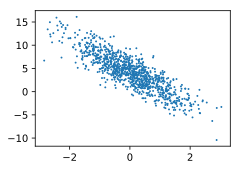

In [6]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('features:', features[0],'\nlabel:', labels[0])

d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

lr = 0.03
num_epochs = 10
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

In [4]:
import pandas as pd
path = "E:/博士内容/分析图/"
data = pd.read_excel(path+ "数据5.2a(百分比).xlsx",sheet_name=None)
data

{'Day1':    Unnamed: 0        Cpu     Memory  Unnamed: 3  Unnamed: 4  Unnamed: 5
 0       Hour1  62.680000  45.841217         NaN         NaN         NaN
 1       Hour2  59.320000  34.224661         NaN         NaN         NaN
 2       Hour3  68.440000  36.816406         NaN         NaN         NaN
 3       Hour4  71.422230  37.131570         NaN         NaN         NaN
 4       Hour5  79.014757  51.860894         NaN         NaN         NaN
 5       Hour6  59.144176  45.467862         NaN         NaN         NaN
 6       Hour7  61.523438  33.349609         NaN         NaN         NaN
 7       Hour8  75.748698  36.124674         NaN         NaN         NaN
 8       Hour9  78.645833  55.574544         NaN         NaN         NaN
 9      Hour10  67.343750  36.679688         NaN         NaN         NaN
 10     Hour11  64.271763  41.685268         NaN         NaN         NaN
 11     Hour12  65.470097  38.230317         NaN         NaN         NaN
 12     Hour13  60.703966  35.239860       

In [16]:
import pandas as pd
import glob

data_list = []  # 创建一个空列表用于存储数据

for path in glob.glob("E:/博士内容/分析图/数据5.2?(百分比).xlsx"):
    data = pd.read_excel(path, sheet_name=None)
    data_list.append(data)  # 将读取的数据添加到列表中

# 现在可以在循环外部使用data_list，例如：
#for data in data_list:
    # 处理数据，进行进一步的操作
    #print(data)
print(data_list)



[{'Day1':    Unnamed: 0        Cpu     Memory  Unnamed: 3  Unnamed: 4  Unnamed: 5
0       Hour1  62.680000  45.841217         NaN         NaN         NaN
1       Hour2  59.320000  34.224661         NaN         NaN         NaN
2       Hour3  68.440000  36.816406         NaN         NaN         NaN
3       Hour4  71.422230  37.131570         NaN         NaN         NaN
4       Hour5  79.014757  51.860894         NaN         NaN         NaN
5       Hour6  59.144176  45.467862         NaN         NaN         NaN
6       Hour7  61.523438  33.349609         NaN         NaN         NaN
7       Hour8  75.748698  36.124674         NaN         NaN         NaN
8       Hour9  78.645833  55.574544         NaN         NaN         NaN
9      Hour10  67.343750  36.679688         NaN         NaN         NaN
10     Hour11  64.271763  41.685268         NaN         NaN         NaN
11     Hour12  65.470097  38.230317         NaN         NaN         NaN
12     Hour13  60.703966  35.239860         NaN       